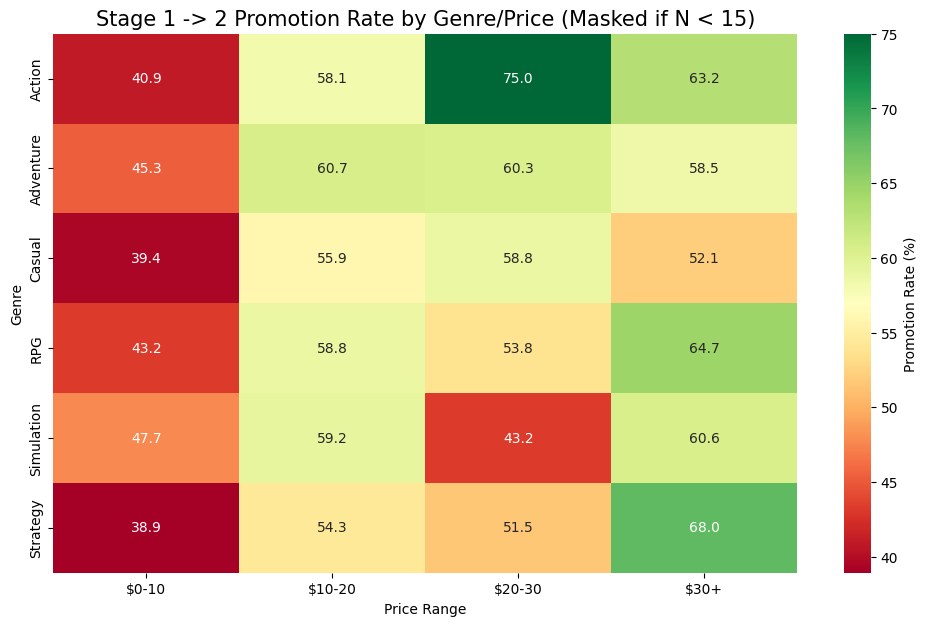


[ 1단계 정체 게임 특성 분석 ]
genres_list price_range  Game_Count  Avg_Sentiment  Avg_Value_Score  Avg_Stability
     Action       $0-10        2766          0.084              0.0            0.0
     Action      $10-20         222          0.788              0.0            0.0
     Action      $20-30          11          0.000              0.0            0.0
     Action        $30+          14          0.000              0.0            0.0
  Adventure       $0-10        2552          0.035              0.0            0.0
  Adventure      $10-20         240          0.955              0.0            0.0
  Adventure      $20-30          23          0.000              0.0            0.0
  Adventure        $30+          17          0.000              0.0            0.0
     Casual       $0-10        3250          0.079              0.0            0.0
     Casual      $10-20         186          0.000              0.0            0.0
     Casual      $20-30          21          0.000              0.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 데이터 로드 및 병합
base_path = '../../../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))
hist_df = pd.read_csv(os.path.join(base_path, 'steam_indie_review_histogram.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)

# 4대 시그널 생성
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')
df = pd.merge(df, stability_stats, on='appid', how='left')

df['sentiment'] = df['positive_rate']
df['safe_owners'] = df['owners_lower'].replace(0, 20000) 
df['value_score'] = df['recommendations_total'].fillna(0) / df['safe_owners']
df[['sentiment', 'value_score', 'stability']] = df[['sentiment', 'value_score', 'stability']].fillna(0)

# 단계 분류 (1단계: 1~9개, 2단계: 10~49개)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 장르 데이터 전처리 (리스트 형태 찌꺼기 문자 제거)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)

# 장르 분리 및 주요 6대 장르 필터링
df_target['genres_list'] = df_target['genres'].str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

# 가격 범위 설정
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)
max_price = df_exploded['price'].max()
if max_price > 1000:
    bins = [-1, 10000, 20000, 30000, float('inf')]
    labels = ['~10,000₩', '10k~20k₩', '20k~30k₩', '30k₩+']
else:
    bins = [-1, 10, 20, 30, float('inf')]
    labels = ['$0-10', '$10-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)

# 1단계 -> 2단계 진입 성공률 시각화
total_counts = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['appid'].count().unstack()
df_exploded['is_promoted'] = (df_exploded['stage'] == 2).astype(int)
success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_promoted'].mean().unstack() * 100

valid_success_map = success_map.where(total_counts >= 15)

plt.figure(figsize=(12, 7))
sns.heatmap(valid_success_map, annot=True, fmt=".1f", cmap="RdYlGn", 
            cbar_kws={'label': 'Promotion Rate (%)'}, mask=valid_success_map.isnull())
plt.title('Stage 1 -> 2 Promotion Rate by Genre/Price (Masked if N < 15)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()

# 1단계 게임들의 평균 지표 비교
stuck_traits = df_exploded[df_exploded['stage'] == 1].groupby(['genres_list', 'price_range'], observed=False).agg(
    Game_Count=('appid', 'count'),
    Avg_Sentiment=('sentiment', 'mean'),
    Avg_Value_Score=('value_score', 'mean'),
    Avg_Stability=('stability', 'mean')
).reset_index()

print("\n[ 1단계 정체 게임 특성 분석 ]")
print(stuck_traits[stuck_traits['Game_Count'] >= 10].round(3).to_string(index=False))

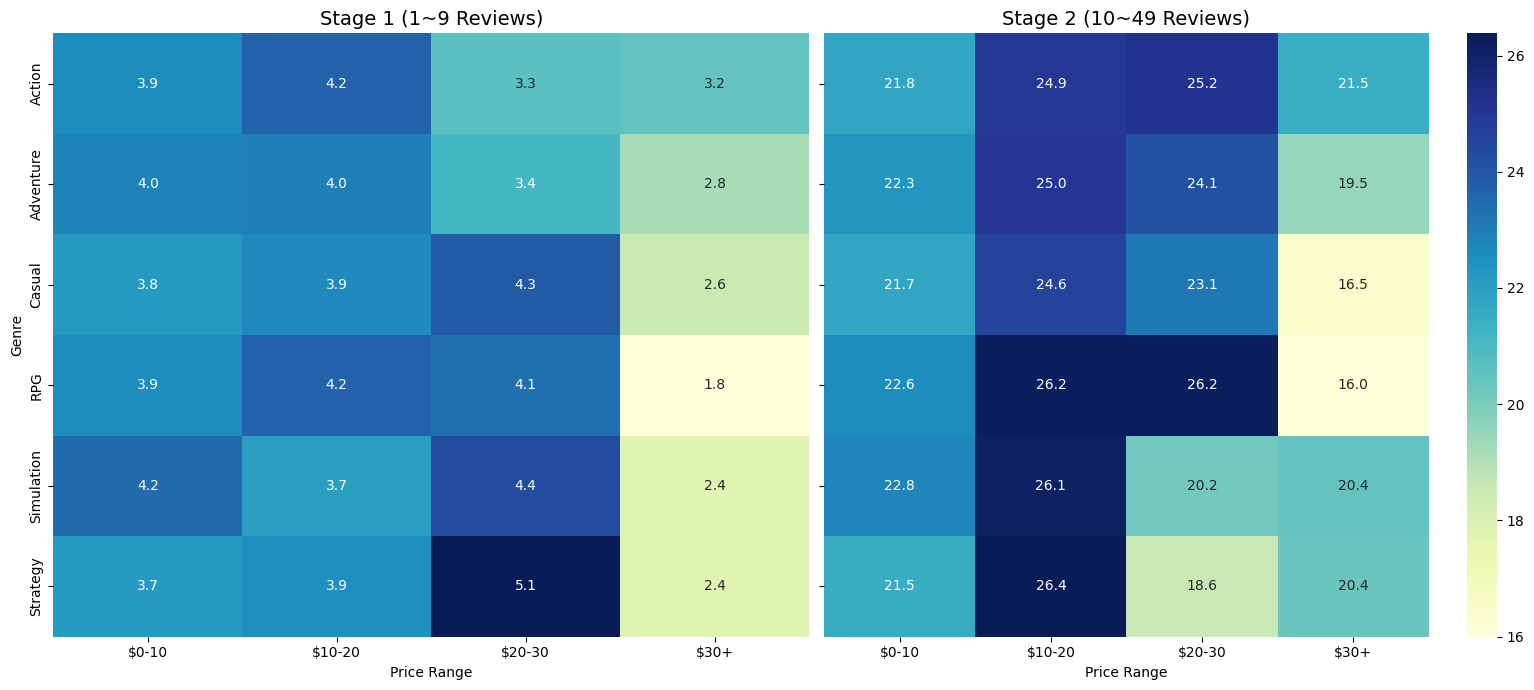


[ 1단계 vs 2단계 장르/가격대별 요약 ]
 stage genres_list price_range  평균_흥행  게임_수
     1      Action       $0-10    3.9  2766
     1      Action      $10-20    4.2   222
     1      Action      $20-30    3.3    11
     1      Action        $30+    3.2    14
     1   Adventure       $0-10    4.0  2552
     1   Adventure      $10-20    4.0   240
     1   Adventure      $20-30    3.4    23
     1   Adventure        $30+    2.8    17
     1      Casual       $0-10    3.8  3250
     1      Casual      $10-20    3.9   186
     1      Casual      $20-30    4.3    21
     1      Casual        $30+    2.6    23
     1         RPG       $0-10    3.9   983
     1         RPG      $10-20    4.2   112
     1         RPG      $20-30    4.1    18
     1         RPG        $30+    1.8     6
     1  Simulation       $0-10    4.2  1075
     1  Simulation      $10-20    3.7   104
     1  Simulation      $20-30    4.4    21
     1  Simulation        $30+    2.4    13
     1    Strategy       $0-10    3.7  1235
     

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 데이터 로드 및 병합
base_path = '../../../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)

# 2. 단계 분류 (0단계 제외, 1단계/2단계만 타겟)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 3. 장르 데이터 클렌징 및 분리 (데이터 증발 방지)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)
df_target['genres_list'] = df_target['genres'].fillna('Unknown').str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

# 4. 가격 범위 설정 (원화/달러 자동 대응)
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)
if df_exploded['price'].max() > 1000:
    bins = [-1, 10000, 20000, 30000, float('inf')]
    labels = ['~10,000₩', '10k~20k₩', '20k~30k₩', '30k₩+']
else:
    bins = [-1, 10, 20, 30, float('inf')]
    labels = ['$0-10', '$10-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)

# 5. 단계별 지표 집계
stats = df_exploded.groupby(['stage', 'genres_list', 'price_range'], observed=False).agg(
    평균_흥행=('total_reviews', 'mean'),
    게임_수=('appid', 'count')
).reset_index()

# 6. 시각화 (Stage 1 vs Stage 2)
stages = [1, 2]
stage_names = {1: 'Stage 1 (1~9 Reviews)', 2: 'Stage 2 (10~49 Reviews)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for i, stage in enumerate(stages):
    subset = stats[stats['stage'] == stage]
    pivoted = subset.pivot(index='genres_list', columns='price_range', values='평균_흥행')
    sns.heatmap(pivoted, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], cbar=(i == 1))
    axes[i].set_title(stage_names[stage], fontsize=14)
    axes[i].set_xlabel("Price Range")
    if i == 0:
        axes[i].set_ylabel("Genre")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

print("\n[ 1단계 vs 2단계 장르/가격대별 요약 ]")
print(stats[stats['게임_수'] > 0].round(1).to_string(index=False))